In [1]:
from typing import TypedDict

class State(TypedDict):
    customer_name: str
    my_age: int

In [9]:
def node_1(state: State):
    return state

def node_2(state: State):
    return state

def node_3(state: State):
    return state

def node_4(state: State):
    return state

In [15]:
import random
from typing import Literal

def route_edge(state: State) -> Literal["node_2", "node_3", "node_4"]:
    if random.random() < 0.33:
        return 'node_2'
    elif random.random() < 0.66:
        return 'node_3'
    else:
        return 'node_4'

In [16]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)

builder.add_edge(START, 'node_1')
builder.add_conditional_edges('node_1', route_edge)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)
builder.add_edge('node_4', END)

agent = builder.compile()

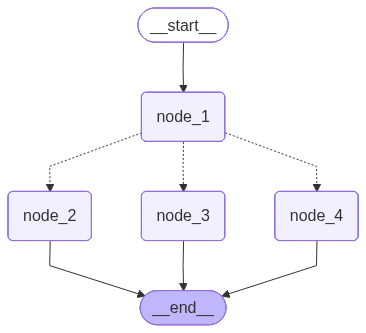

In [17]:
from IPython.display import Image, display
#print(agent.get_graph().draw_ascii())
display(Image(agent.get_graph().draw_mermaid_png()))

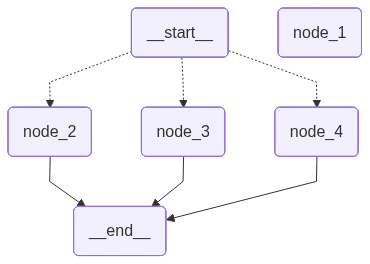

In [19]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)

builder.add_conditional_edges(START, route_edge)
builder.add_edge('node_1', END)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)
builder.add_edge('node_4', END)

agent = builder.compile()
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))